In [52]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report
from scipy.stats import zscore
import seaborn as sns
import matplotlib.pyplot as plt

In [53]:
# Load data (replace 'hepatitis.csv' with your file path if needed)
df = pd.read_csv("hepatitis.csv", header=None)

# Optional: assign column names
df.columns = [
    "Class", "Age", "Sex", "Steroid", "Antivirals", "Fatigue", "Malaise", "Anorexia",
    "LiverBig", "LiverFirm", "SpleenPalpable", "Spiders", "Ascites", "Varices",
    "Bilirubin", "AlkPhosphate", "SGOT", "Albumin", "Protime", "Histology"
]

# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

# Convert all to numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Remove rows with any missing values
df.dropna(inplace=True)

# Remove negative values (not expected in medical data)
df = df[(df >= 0).all(axis=1)]

print("Data shape after cleaning:", df.shape)

Data shape after cleaning: (80, 20)


In [54]:
df.head()

,Class,Age,Sex,Steroid,Antivirals,Fatigue,Malaise,Anorexia,LiverBig,LiverFirm,SpleenPalpable,Spiders,Ascites,Varices,Bilirubin,AlkPhosphate,SGOT,Albumin,Protime,Histology
5,2,34,1,2.0,2,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.9,95.0,28.0,4.0,75.0,1
10,2,39,1,1.0,1,2.0,2.0,2.0,1.0,1.0,2.0,2.0,2.0,2.0,1.3,78.0,30.0,4.4,85.0,1
11,2,32,1,2.0,1,1.0,2.0,2.0,2.0,1.0,2.0,1.0,2.0,2.0,1.0,59.0,249.0,3.7,54.0,1
12,2,41,1,2.0,1,1.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,0.9,81.0,60.0,3.9,52.0,1
13,2,30,1,2.0,2,1.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.2,57.0,144.0,4.9,78.0,1


In [55]:
# Remove outliers using z-score for numeric features
numeric_cols = ["Age", "Bilirubin", "AlkPhosphate", "SGOT", "Albumin", "Protime"]
z_scores = np.abs(zscore(df[numeric_cols]))
df = df[(z_scores < 3).all(axis=1)]

print("Data shape after outlier removal:", df.shape)

Data shape after outlier removal: (74, 20)


In [56]:
# Features and target
X = df.drop("Class", axis=1)
y = df["Class"]  # 1 = DIE, 2 = LIVE

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

In [57]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

lr_acc = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", lr_acc)
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8695652173913043
              precision    recall  f1-score   support

           1       1.00      0.25      0.40         4
           2       0.86      1.00      0.93        19

    accuracy                           0.87        23
   macro avg       0.93      0.62      0.66        23
weighted avg       0.89      0.87      0.84        23



In [58]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

nb_acc = accuracy_score(y_test, y_pred_nb)
print("Naive Bayes Accuracy:", nb_acc)
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.9130434782608695
              precision    recall  f1-score   support

           1       0.67      1.00      0.80         4
           2       1.00      0.89      0.94        19

    accuracy                           0.91        23
   macro avg       0.83      0.95      0.87        23
weighted avg       0.94      0.91      0.92        23



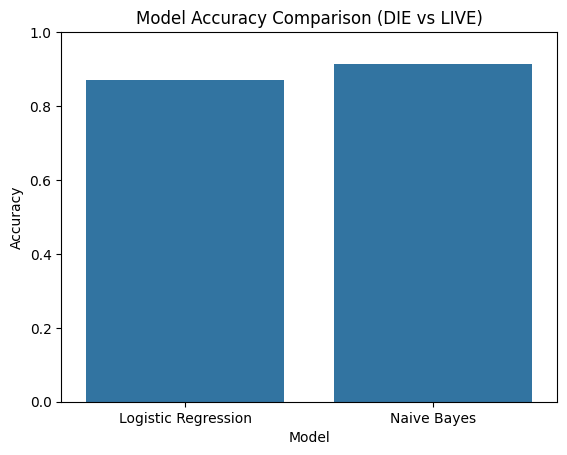

In [59]:
# Accuracy bar plot
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes'],
    'Accuracy': [lr_acc, nb_acc]
})

sns.barplot(x='Model', y='Accuracy', data=results)
plt.title("Model Accuracy Comparison (DIE vs LIVE)")
plt.ylim(0, 1)
plt.show()